<a href="https://colab.research.google.com/github/parth0047/Machine-Learning-with-Python-Custom-Models/blob/main/Logistic_Regression_And_KNN_Maintaince_Dataset_Prat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Maintance Dataset

In [ ]:
#importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Reading and Studying the Dataset
main = pd.read_csv('/content/drive/MyDrive/CTTC Course/DATASET/maintenance_data.csv')
main.head()

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1


In [ ]:
main.dtypes

,0
lifetime,int64
broken,int64
pressureInd,float64
moistureInd,float64
temperatureInd,float64
team,object
provider,object


In [ ]:
main.isnull().sum()

,0
lifetime,0
broken,0
pressureInd,0
moistureInd,0
temperatureInd,0
team,0
provider,0


In [ ]:
for i in main.columns:
  print(i)
  print(main[i].unique())
  print()

lifetime
[56 81 60 86 34 30 68 65 23 38 29 82 80 48 92 88 74 61 35 26 63 79 53 73
 13 36 31 25 58 19 84 12 15 43  1 20 16  3 18  7 47 39 57  4 24 28 49 76
 52  8 40 46  5 41 93 77 62 85 55 33 17 45  9 72 50 42 44 54 64 27 22 59
 66 83 14 51 71 21 78  6 69 89  2 67 87 11 10 32 37 90]

broken
[0 1]

pressureInd
[ 92.17885406  72.07593772  96.27225443  94.40646126  97.75289859
  87.67880097  94.61417404  96.48330289 105.486158    99.17823531
  97.81784409  67.81225145  86.36611059  76.14465414 103.1072633
  88.41407945  84.35504868  79.66925455  86.22910861  84.17942039
 100.0059233  115.6075596   97.69718903 101.4156229  118.9786971
 102.1127749  129.1243378  109.0330362  107.2980695  127.2639544
 138.1911205   72.55408417  95.21464918  91.24713174  81.55537698
  69.13459519 132.8574784   54.73533145  84.89864628  94.15228726
  84.34406647  95.75352436 123.9284399  101.5053508  120.9455502
  83.06857115 113.3491219   75.64669299 113.4358321   81.77978353
  68.85065142 150.665421    72.42

In [ ]:
import warnings
warnings.filterwarnings('ignore')

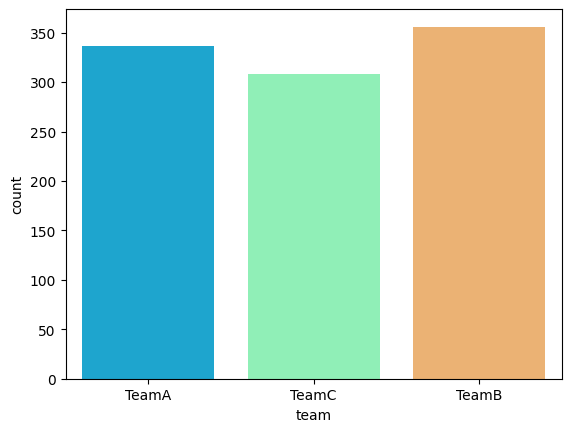

In [ ]:
sns.countplot(x=main.team,palette='rainbow')
plt.show()

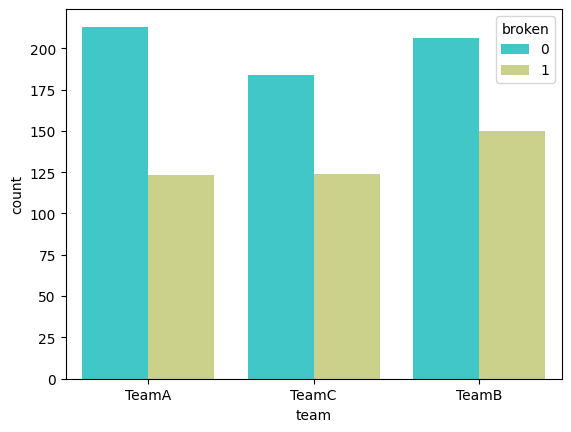

In [ ]:
sns.countplot(x=main.team,hue=main.broken,palette='rainbow')
plt.show()

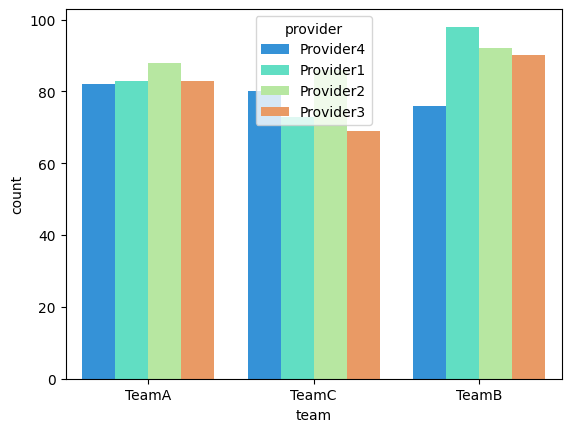

In [ ]:
sns.countplot(x=main.team,hue=main.provider,palette='rainbow')
plt.show()

## Encoding : It is use to convert string to numeric.
Type of Encoding


*   Label Encoding

*   One-Hot Encoding
*   Dummy Encoding



*   Target Encoding

*   Ordinal Encoding
*   Frequency Encoding





In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
#transforming the Team data in main
main.team = le.fit_transform(main.team)
main.team.unique()

array([0, 2, 1])

In [ ]:
le.inverse_transform([0,1,2])

array(['TeamA', 'TeamB', 'TeamC'], dtype=object)

In [ ]:
#transforming the provider data in main
main.provider = le.fit_transform(main.provider)
main.provider.unique()
le.inverse_transform([0,1,2,3])

array(['Provider1', 'Provider2', 'Provider3', 'Provider4'], dtype=object)

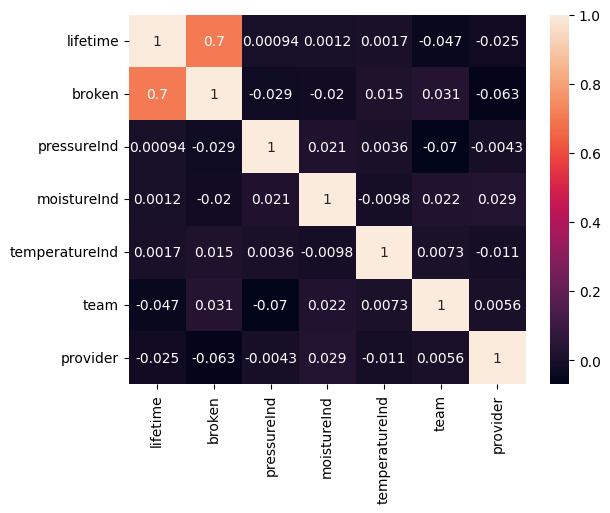

In [ ]:
#heatmap
sns.heatmap(main.corr(),annot=True)
plt.show()
#

#Machine learning

In [ ]:
#ip/op Creation
ip = main.drop('broken',axis=1)
op = main.broken


In [ ]:
#Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ip,op,test_size=0.2)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 6)
(200, 6)
(800,)
(200,)


In [ ]:
#Scaling
#Standard Scaler Transform
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
#prediction
pred = lr.predict(x_test)
pred
#

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0])

In [ ]:
y_test

,broken
908,1
700,1
672,1
70,0
579,1
...,...
852,1
113,1
676,1
309,0


In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
ac = accuracy_score(y_test,pred)
re = recall_score(y_test,pred)
pr = precision_score(y_test,pred)
f1 = f1_score(y_test,pred)
print('Accuracy : ',ac*100)
print('Recall : ',re*100)
print('Precision : ',pr*100)
print('F1 Score : ',f1*100)
#

Accuracy :  78.0
Recall :  70.23809523809523
Precision :  75.64102564102564
F1 Score :  72.8395061728395


In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay
cm = confusion_matrix(y_test,pred)
cm

array([[97, 19],
       [25, 59]])

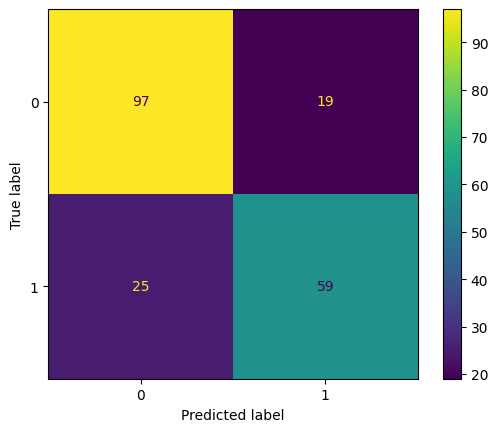

In [ ]:
cmdisp = ConfusionMatrixDisplay(cm)
cmdisp.plot()
plt.show()
#

In [ ]:
df = pd.DataFrame({'Actual':list(y_test),'Predicted':pred})
df

,Actual,Predicted
0,1,1
1,1,1
2,1,0
3,0,0
4,1,1
...,...,...
195,1,1
196,1,1
197,1,0
198,0,0


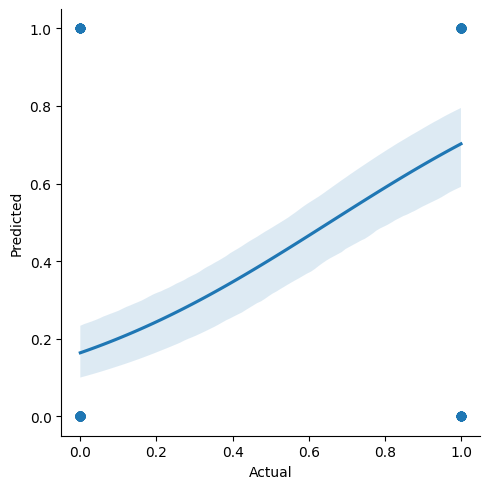

In [ ]:
#lmpot
sns.lmplot(data=df,x='Actual',y='Predicted',logistic=True)
plt.show()
#

#KNN
## K-Nearest Neighbour

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
knn_pred = knn.predict(x_test)
knn_pred

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0])

In [ ]:
knn_pred = pd.DataFrame(knn_pred)
knn_pred
#

,0
0,0
1,1
2,0
3,0
4,1
...,...
195,1
196,0
197,1
198,0


In [ ]:
ac = accuracy_score(y_test,knn_pred)
re = recall_score(y_test,knn_pred)
pr = precision_score(y_test,knn_pred)
f1 = f1_score(y_test,knn_pred)
print('Accuracy : ',ac*100)
print('Recall : ',re*100)
print('Precision : ',pr*100)
print('F1 Score : ',f1*100)
#

Accuracy :  79.5
Recall :  80.95238095238095
Precision :  73.11827956989248
F1 Score :  76.8361581920904


In [ ]:
cm = confusion_matrix(y_test,knn_pred)
cm

array([[91, 25],
       [16, 68]])

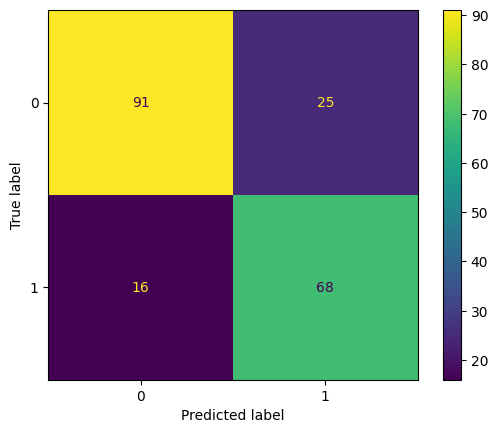

In [ ]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()
#

#Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [ ]:
#Prediction
gnb_pred = gnb.predict(x_test)
gnb_pred

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0])

In [ ]:
ac = accuracy_score(y_test,gnb_pred)
re = recall_score(y_test,gnb_pred)
pr = precision_score(y_test,gnb_pred)
f1 = f1_score(y_test,gnb_pred)
print('Accuracy : ',ac*100)
print('Recall : ',re*100)
print('Precision : ',pr*100)
print('F1 Score :',f1*100)
#

Accuracy :  83.5
Recall :  84.52380952380952
Precision :  78.02197802197803
F1 Score : 81.14285714285714


In [ ]:
cm = confusion_matrix(y_test,gnb_pred)
cm
#

array([[96, 20],
       [13, 71]])

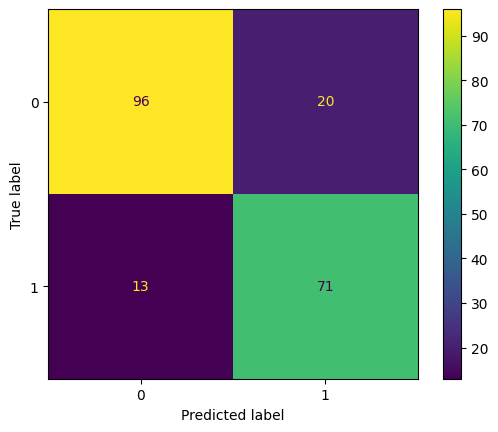

In [ ]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()
#

#SVM (Support Vector Machine)
##SVC: Support Vector Classifier

In [ ]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf',gamma=1,C=1000)
svc.fit(x_train,y_train)

SVC(C=1000, gamma=1)

In [ ]:
svm_pred = svc.predict(x_test)
svm_pred

array([1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0])

In [ ]:
ac = accuracy_score(y_test,svm_pred)
re = recall_score(y_test,svm_pred)
pr = precision_score(y_test,svm_pred)
f1 = f1_score(y_test,svm_pred)
print('Accuracy : ',ac*100)
print('Recall : ',re*100)
print('Precision : ',pr*100)
print('F1 Score : ',f1*100)
#

Accuracy :  83.0
Recall :  78.57142857142857
Precision :  80.48780487804879
F1 Score :  79.51807228915662


In [ ]:
cm = confusion_matrix(y_test,svm_pred)
cm

array([[100,  16],
       [ 18,  66]])

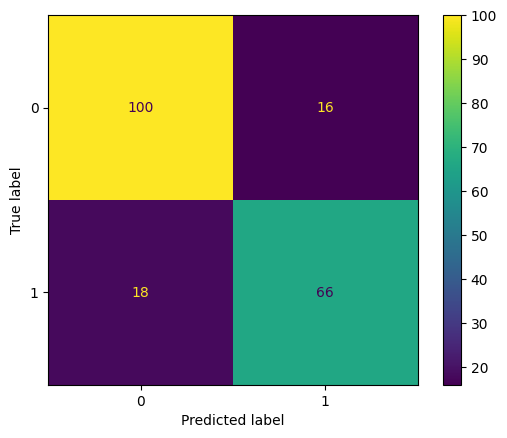

In [ ]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()
#